In [1]:
### Import analysis data ###

import sys
sys.path.append('../src')


import jax
import jax.numpy as jnp
import os
import numpy as np
from pinn.train import create_train_state
from pinn.cryoet_io import load_mrc_data
from flax.training import checkpoints

### PARAMETERS ###
GRID_SIZE = 64
lambda_1 = 1000000      # Weight for data loss
lambda_2 = 0            # Weight for physics loss
shape = "bud_04"
flip_ratio=0.15
# wedge_axis='z'
num_collocation = 10000
step = 10000

str_flip = str(flip_ratio).replace('.', '')

### CREATE TRAIN STATE ###
key = jax.random.PRNGKey(0)
state, _ = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2)

### LOAD CHECKPOINT DATA ###
checkpoint_path = os.path.abspath(f"../outputs/logs/{shape}/data_1016/f{str_flip}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
params_star = checkpoint_data["state"]["params"]

### LOAD MRC DATA ###
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

### COLLOCATION POINTS ###
x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1))

Resizing MRC data from (128, 128, 128) to (64, 64, 64)


In [13]:
import jax
from pinn.hessian import build_curvature_tools
from pinn.model import loss_data, loss_physics

# Your compute_losses as given:
def compute_losses(params):
    phi_fn = lambda x: state.apply_fn(params, x.reshape(-1, 3))
    loss_data_val    = loss_data(phi_fn, cryoET_data, state.threshold)
    loss_physics_val = loss_physics(phi_fn, x_train)
    return state.lambda_1 * loss_data_val + state.lambda_2 * loss_physics_val
    # return state.lambda_1 * loss_data_val
    # return state.lambda_2 * loss_physics_val

HVP, lanczos_topk, hutchinson_trace = build_curvature_tools(compute_losses)

key = jax.random.PRNGKey(0)

# Top-k eigenpairs
eigs, vecs, residuals, cosines = lanczos_topk(params_star, key, k=30)
print("\nTop eigenvalues:\n", eigs)
print("Residual norms ||Hv - λv|| / λ:\n", residuals/eigs)
print("Cosine alignment cos(Hv, v):\n", cosines)

# Trace estimate
trace_mean, trace_std = hutchinson_trace(params_star, num_probes=16, key=jax.random.PRNGKey(1))
print(f"\nHutchinson trace(H) ≈ {float(trace_mean):.4f} ± {float(trace_std):.4f} (std)")



Top eigenvalues (descending):
 [890716.2   532146.    372265.06  264987.72  209063.8   157712.6
 118601.23  104383.71   85617.33   73136.77   62182.52   59181.91
  51697.008  42546.94   39327.98   38159.676  35138.293  33916.152
  30490.885  29437.213  27381.178  26291.018  23768.49   22329.865
  21682.135  20805.086  19696.938  18638.54   18032.422  16880.96 ]
Residual norms ||Hv - λv|| / λ:
 [3.6787560e-07 5.3121300e-07 5.3217633e-07 5.7278902e-07 1.0105686e-06
 8.1321332e-07 9.0847107e-07 1.0200025e-06 8.5177948e-07 1.8685369e-06
 1.3140188e-06 9.4405891e-07 1.2621648e-06 1.6519608e-06 3.5591979e-06
 4.6049872e-06 1.7746142e-06 1.5678399e-06 3.4220807e-06 2.7065526e-06
 3.3332592e-06 2.7626593e-06 1.7646542e-05 1.9302366e-03 1.5268729e-03
 8.5891904e-03 1.3424705e-02 4.7450632e-02 2.6113342e-02 3.9688013e-02]
Cosine alignment cos(Hv, v):
 [1.0000001  1.         1.0000001  1.0000001  1.0000001  1.
 1.         1.0000001  1.0000001  0.99999994 1.         1.
 0.9999999  1.0000001  1.00

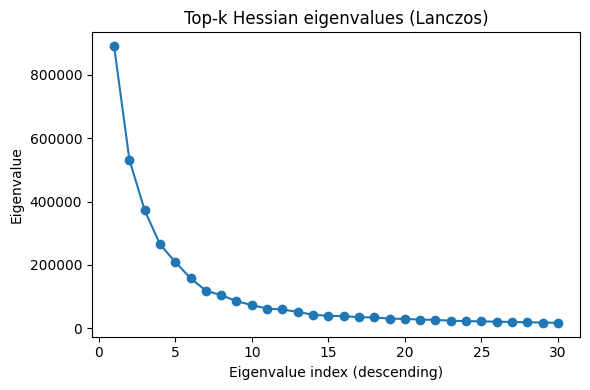

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
xs = jnp.arange(1, eigs.shape[0]+1)
plt.plot(xs, eigs, marker='o')
plt.xlabel("Eigenvalue index (descending)")
plt.ylabel("Eigenvalue")
plt.title("Top-k Hessian eigenvalues (Lanczos)")
plt.tight_layout()
plt.show()

In [37]:
### One-frame three components analysis ###

import jax
from pinn.hessian import build_curvature_tools
from pinn.model import loss_data, loss_physics
from functools import partial

key = jax.random.PRNGKey(0)

def compute_losses(params, which):
    phi_fn = lambda x: state.apply_fn(params, x.reshape(-1, 3))
    loss_data_val    = loss_data(phi_fn, cryoET_data, state.threshold)
    loss_physics_val = loss_physics(phi_fn, x_train)
    if which == 'data':
        loss_val = state.lambda_1 * loss_data_val
    elif which == 'physics':
        loss_val = state.lambda_2 * loss_physics_val
    else:
        loss_val = state.lambda_1 * loss_data_val + state.lambda_2 * loss_physics_val
    return loss_val

eigs_dict = {}
trace_mean_dict = {}
trace_std_dict = {}

for which in ['data', 'physics', 'total']:
    HVP, lanczos_topk, hutchinson_trace = build_curvature_tools(partial(compute_losses, which=which))
    eigs, vecs, residuals, cosines = lanczos_topk(params_star, key, k=30)
    # print("\nTop eigenvalues:\n", eigs)
    # print("Residual norms ||Hv - λv|| / λ:\n", residuals/eigs)
    # print("Cosine alignment cos(Hv, v):\n", cosines)    
    trace_mean, trace_std = hutchinson_trace(params_star, num_probes=16, key=jax.random.PRNGKey(1))
    # print(f"\nHutchinson trace(H) ≈ {float(trace_mean):.4f} ± {float(trace_std):.4f} (std)")
    eigs_dict[which] = eigs
    trace_mean_dict[which] = trace_mean
    trace_std_dict[which] = trace_std

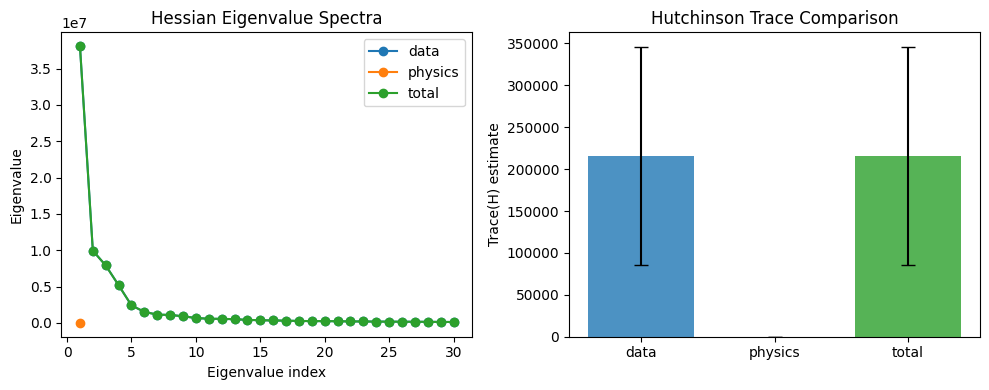

In [38]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

labels = ['data', 'physics', 'total']
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# -------- Left: Top-k Eigenvalue Spectra --------
for i, which in enumerate(labels):
    eigs = jnp.array(eigs_dict[which])
    axes[0].plot(
        jnp.arange(1, len(eigs) + 1),
        eigs,
        marker='o',
        label=which,
        color=colors[i]
    )
axes[0].set_xlabel("Eigenvalue index")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_title("Hessian Eigenvalue Spectra")
axes[0].legend()

# -------- Right: Hutchinson Trace Comparison --------
trace_means = [float(trace_mean_dict[w]) for w in labels]
trace_stds  = [float(trace_std_dict[w]) for w in labels]

axes[1].bar(labels, trace_means, yerr=trace_stds, color=colors, alpha=0.8, capsize=5)
axes[1].set_ylabel("Trace(H) estimate")
axes[1].set_title("Hutchinson Trace Comparison")

plt.tight_layout()
plt.show()

In [1]:
### Import analysis data over steps ###

import sys
sys.path.append('../src')

import jax
import jax.numpy as jnp
import os
import numpy as np
from pinn.train import create_train_state
from pinn.cryoet_io import load_mrc_data
from flax.training import checkpoints

### PARAMETERS ###
GRID_SIZE = 64
lambda_1 = 1000000      # Weight for data loss
lambda_2 = 30           # Weight for physics loss
shape = "bud_04"
flip_ratio=0.2
# wedge_axis='z'
num_collocation = 10000
step_seq = list(range(0, 10001, 100))
# step_seq = list(range(0, 3001, 100))
version = "0926/plane"

str_flip = str(flip_ratio).replace('.', '')

### CREATE TRAIN STATE ###
key = jax.random.PRNGKey(0)
state, _ = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2)

### LOAD CHECKPOINT DATA ###
params_seq = {}
for step in step_seq:
    checkpoint_path = os.path.abspath(f"../outputs/logs/{shape}/data_{version}/f{str_flip}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
    checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
    params_star = checkpoint_data["state"]["params"]
    params_seq[step] = params_star

### LOAD MRC DATA ###
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

### COLLOCATION POINTS ###
x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1))

Resizing MRC data from (128, 128, 128) to (64, 64, 64)


In [2]:
### Analysis over steps ###

import jax
from pinn.hessian import build_curvature_tools, tree_dot
from pinn.model import loss_data, loss_physics
from functools import partial
from tqdm import tqdm

base_key = jax.random.PRNGKey(0)
k = 10
num_probes = 16

def compute_losses(params, which):
    phi_fn = lambda x: state.apply_fn(params, x.reshape(-1, 3))
    loss_data_val    = loss_data(phi_fn, cryoET_data, state.threshold)
    loss_physics_val = loss_physics(phi_fn, x_train)
    if which == 'data':
        loss_val = state.lambda_1 * loss_data_val
    elif which == 'physics':
        loss_val = state.lambda_2 * loss_physics_val
    else:
        loss_val = state.lambda_1 * loss_data_val + state.lambda_2 * loss_physics_val
    return loss_val


which_list = ['data', 'physics', 'total']
tools = {
    w: build_curvature_tools(partial(compute_losses, which=w))
    for w in which_list
}
loss_fns = {w: partial(compute_losses, which=w) for w in which_list}
grad_fns = {w: jax.jit(jax.grad(loss_fns[w])) for w in which_list}

# results[step]['eigs'][which]  -> eigenvalues (length k)
# results[step]['trace'][which] -> {'mean': float, 'std': float}
# results[step]['loss'][which]  -> scalar loss values
# results[step]['grad'][which]  -> scalar grad values
results = {}

for si, step in enumerate(tqdm(step_seq, desc="Hessian analysis")):
    params_star = params_seq[step]
    step_key, probe_key = jax.random.split(jax.random.fold_in(base_key, si))
    results[step] = {'eigs': {}, 'trace': {}, 'loss': {}, 'grad': {}}

    for which in which_list:
        HVP, lanczos_topk, hutchinson_trace = tools[which]
        eigs, vecs, residuals, cosines = lanczos_topk(params_star, step_key, k=k)
        results[step]['eigs'][which] = eigs
        tm, ts = hutchinson_trace(params_star, num_probes=num_probes, key=probe_key)
        results[step]['trace'][which] = {'mean': tm, 'std': ts}
        # results[step]['loss'][which] = loss_fns[which](params_star)
        # grads = grad_fns[which](params_star)
        # grad_norm = jnp.sqrt(tree_dot(grads, grads))
        # results[step]['grad'][which] = float(grad_norm)


Hessian analysis: 100%|██████████████████████████████████| 101/101 [05:09<00:00,  3.07s/it]


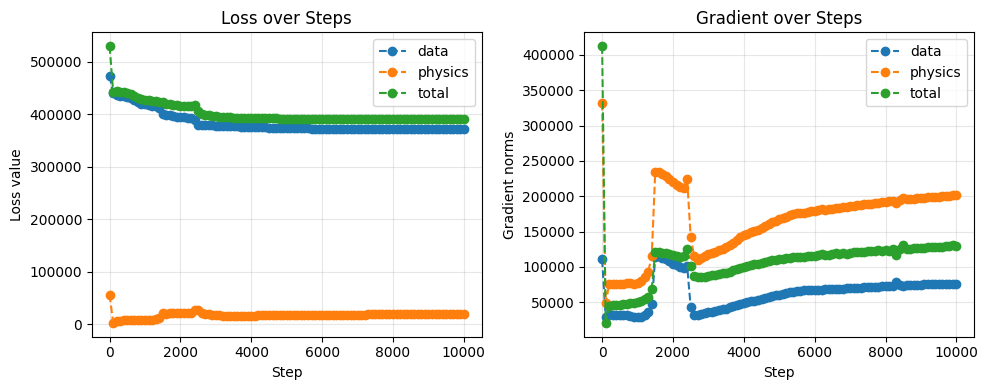

In [37]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

which_list = ['data', 'physics', 'total']
colors = {'data': 'tab:blue', 'physics': 'tab:orange', 'total': 'tab:green'}

# which_list = ['data', 'total']
# colors = {'data': 'tab:blue', 'total': 'tab:green'}

# which_list = ['physics']
# colors = {'physics': 'tab:orange'}

steps = list(step_seq)
# steps = list(range(0, 3001, 100))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# ---------- Left: Hutchinson Trace ----------
ax = axes[0]
for which in which_list:
    loss_vals = [float(results[step]['loss'][which]) for step in steps]
    ax.plot(
        steps,
        loss_vals,
        linestyle='--',
        marker='o',
        color=colors[which],
        label=which
    )
ax.set_xlabel("Step")
ax.set_ylabel("Loss value")
ax.set_title("Loss over Steps")
ax.legend()
ax.grid(alpha=0.3)

# ---------- Right: Loss ----------
ax = axes[1]
for which in which_list:
    grad_vals = [float(results[step]['grad'][which]) for step in steps]
    # rel_grad  = [float(results[step]['grad'][which]) / float(results[step]['loss'][which]) for step in steps]
    ax.plot(
        steps,
        grad_vals,
        # rel_grad,
        linestyle='--',
        marker='o',
        color=colors[which],
        label=which
    )
ax.set_xlabel("Step")
ax.set_ylabel("Gradient norms")
ax.set_title("Gradient over Steps")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


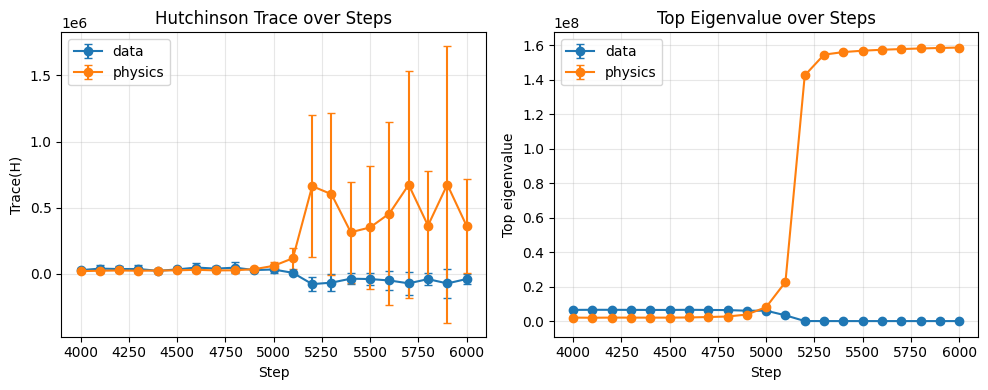

In [6]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

# which_list = ['data', 'physics', 'total']
# colors = {'data': 'tab:blue', 'physics': 'tab:orange', 'total': 'tab:green'}

# which_list = ['data', 'total']
# colors = {'data': 'tab:blue', 'total': 'tab:green'}

# which_list = ['physics']
# colors = {'physics': 'tab:orange'}

which_list = ['data', 'physics']
colors = {'data': 'tab:blue', 'physics': 'tab:orange'}

steps = list(step_seq)
steps = list(range(4000, 6001, 100))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# ---------- Left: Hutchinson Trace ----------
ax = axes[0]
for which in which_list:
    trace_means = [float(results[step]['trace'][which]['mean']) for step in steps]
    trace_stds  = [float(results[step]['trace'][which]['std'] ) for step in steps]
    ax.errorbar(
        steps,
        trace_means,
        yerr=trace_stds,
        marker='o',
        color=colors[which],
        capsize=3,
        label=which
    )
ax.set_xlabel("Step")
ax.set_ylabel("Trace(H)")
ax.set_title("Hutchinson Trace over Steps")
ax.legend()
ax.grid(alpha=0.3)

# ---------- Right: Loss ----------
ax = axes[1]
for which in which_list:
    top_eigs = [float(results[step]['eigs'][which][0]) for step in steps]
    ax.errorbar(
        steps,
        top_eigs,
        yerr=trace_stds,
        marker='o',
        color=colors[which],
        capsize=3,
        label=which
    )
ax.set_xlabel("Step")
ax.set_ylabel("Top eigenvalue")
ax.set_title("Top Eigenvalue over Steps")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [115]:
from pinn.hessian import tree_norm
grad_norm_total = results[10000]['grad']['total']  # float
param_norm = tree_norm(params_star)                 # params is still a PyTree
rel_grad = grad_norm_total / param_norm
print("relative grad:", rel_grad)

relative grad: 5531.4727


In [120]:
# 1) Absolute values behind the ratio
grad_norm_total = results[10000]['grad']['total']      # float
param_norm_total = tree_norm(params_star)              # PyTree norm
print("grad_norm:", grad_norm_total)
print("param_norm:", float(param_norm_total))
print("ratio:", grad_norm_total / float(param_norm_total))

# 2) If you have Flax variables, ensure only 'params' are included
# (your params_star already look like {'params': {...}}; that's OK)

# 3) Per-layer parameter/gradient norms (find culprits)
def tree_l2(t): 
    import jax.numpy as jnp, jax.tree_util as jtu
    leaves, _ = jtu.tree_flatten(t)
    return float(jnp.sqrt(sum(jnp.vdot(x, x) for x in leaves)))

g_total = jax.grad(lambda p: compute_losses(p, 'total'))(params_star)
print("per-layer stats:")
import jax.tree_util as jtu, jax.numpy as jnp
def stats(p, g):
    return dict(p_l2=float(jnp.sqrt(jnp.vdot(p,p))),
                g_l2=float(jnp.sqrt(jnp.vdot(g,g))),
                ratio=float(jnp.sqrt(jnp.vdot(g,g)) / (jnp.sqrt(jnp.vdot(p,p)) + 1e-12)))
layer_stats = jtu.tree_map(stats, params_star['params'], g_total['params'])
print(layer_stats)


grad_norm: 75635.671875
param_norm: 13.67369556427002
ratio: 5531.472564932586
per-layer stats:
{'Dense_0': {'bias': {'p_l2': 1.727927565574646, 'g_l2': 48173.6953125, 'ratio': 27879.46484375}, 'kernel': {'p_l2': 6.71370792388916, 'g_l2': 27740.435546875, 'ratio': 4131.90966796875}}, 'Dense_1': {'bias': {'p_l2': 1.5360736846923828, 'g_l2': 20801.5234375, 'ratio': 13542.0087890625}, 'kernel': {'p_l2': 10.575973510742188, 'g_l2': 33433.8359375, 'ratio': 3161.30126953125}}, 'Dense_2': {'bias': {'p_l2': 0.42280957102775574, 'g_l2': 7400.060546875, 'ratio': 17502.111328125}, 'kernel': {'p_l2': 4.951851844787598, 'g_l2': 32019.25, 'ratio': 6466.1162109375}}}


In [125]:
import jax, jax.numpy as jnp, jax.tree_util as jtu

def tree_sub(a,b): return jtu.tree_map(lambda x,y: x-y, a, b)

params_t  = params_seq[step_seq[-2]]
params_t1 = params_seq[step_seq[-1]]

def tree_dot(a,b):
    la,_=jtu.tree_flatten(a); lb,_=jtu.tree_flatten(b)
    return sum(jnp.vdot(x,y) for x,y in zip(la,lb))
def tree_norm(t): return jnp.sqrt(tree_dot(t,t))

rel_update = float(tree_norm(tree_sub(params_t1, params_t)) / (tree_norm(params_t1) + 1e-12))
print("relative update:", rel_update)


relative update: 0.006739531643688679


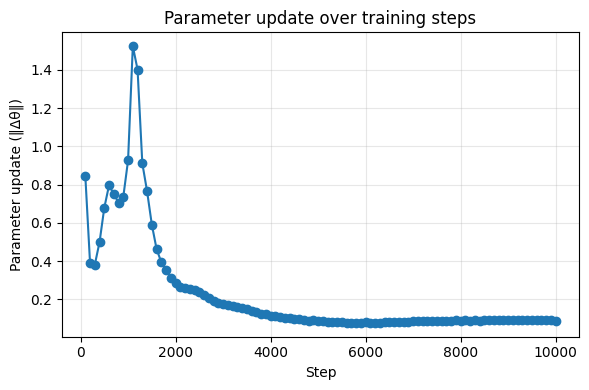

In [136]:
import jax
import jax.numpy as jnp
import jax.tree_util as jtu
import matplotlib.pyplot as plt

def tree_sub(a, b):
    return jtu.tree_map(lambda x, y: x - y, a, b)

def tree_dot(a, b):
    la, _ = jtu.tree_flatten(a)
    lb, _ = jtu.tree_flatten(b)
    return sum(jnp.vdot(x, y) for x, y in zip(la, lb))

def tree_norm(t):
    return jnp.sqrt(tree_dot(t, t))

# Compute relative updates over step_seq
rel_updates = []
for i in range(1, len(step_seq)):
    params_prev = params_seq[step_seq[i - 1]]
    params_curr = params_seq[step_seq[i]]
    rel_update = float(
        tree_norm(tree_sub(params_curr, params_prev))
        # / (tree_norm(params_curr) + 1e-12)
    )
    rel_updates.append(rel_update)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(step_seq[1:], rel_updates, marker='o', linestyle='-')
plt.xlabel("Step")
# plt.ylabel("Relative update (‖Δθ‖ / ‖θ‖)")
plt.ylabel("Parameter update (‖Δθ‖)")
plt.title("Parameter update over training steps")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [162]:
params_star = params_seq[3000]
g_data = jax.grad(partial(compute_losses, which='data'))(params_star)
g_phys = jax.grad(partial(compute_losses, which='physics'))(params_star)
cos_angle = tree_dot(g_data, g_phys) / (tree_norm(g_data) * tree_norm(g_phys))
print("cos(angle) =", cos_angle)


cos(angle) = -0.2282873
